# 005 数据管线与可视化检查

从空内核顺序运行。主任务为未见设备的09:00预测；晚到读数在09:05才可用。数据全为公开原创合成练习，不是真实盲测。正式管线不评分主数据测试标签。

In [1]:
from pathlib import Path
import json, copy
import numpy as np
import experiment as e
print("NumPy", np.__version__)
print("features", e.FEATURES)

NumPy 2.3.5
features ('knob1', 'knob2')


## 1 观测身份
预测13行中哪一行应去掉，解释为什么A01和A02都应保留。

In [2]:
raw = e.read_csv(e.ROOT / "data/records_raw.csv")
rows, removed = e.clean_records(raw)
print("raw / unique:", len(raw), len(rows))
print("removed copies:", removed)
print("device A observations:", [r["record_id"] for r in rows if r["device_id"] == "A"])
assert (len(raw), len(rows), removed) == (13, 12, ["A02"])

raw / unique: 13 12
removed copies: ['A02']
device A observations: ['A01', 'A02']


## 2 按ID连接倒序标签
先看错位的可能，再检查正确连接。形状相等无法证明配对正确。

In [3]:
labels = e.read_csv(e.ROOT / "data/labels.csv")
joined = e.join_labels(rows, labels)
print("first raw label:", labels[0])
print("joined first:", joined[0]["record_id"], joined[0]["target"])
assert joined[0]["target"] == 2

first raw label: {'record_id': 'F02', 'target': '47.0', 'label_available_time': '2026-01-02T09:05:00'}
joined first: A01 2.0


## 3 固定实体名单
验证A/B/C、D、E/F分别出现在哪一侧。若目标改为既有设备未来预测，必须另写时间约束，不能直接复用这项结论。

In [4]:
lists = json.loads((e.ROOT / "data/entity_split.json").read_text())
parts = e.split_records(joined, lists)
X = {name: e.feature_matrix(group) for name, group in parts.items()}
for name in lists:
    print(name, lists[name], X[name].shape)
print(json.dumps(e.describe(X["train"]), indent=2))

train ['A01', 'A02', 'B01', 'B02', 'C01', 'C02'] (6, 2)
validation ['D01', 'D02'] (2, 2)
test ['E01', 'E02', 'F01', 'F02'] (4, 2)
{
  "knob1": {
    "rows": 6,
    "observed": 6,
    "missing": 0,
    "missing_fraction": 0.0,
    "sum": 21.0,
    "mean": 3.5,
    "min": 1.0,
    "max": 6.0
  },
  "knob2": {
    "rows": 6,
    "observed": 5,
    "missing": 1,
    "missing_fraction": 0.16666666666666666,
    "sum": 190.0,
    "mean": 38.0,
    "min": 10.0,
    "max": 60.0
  }
}


## 4 只拟合训练
手算旋钮2：190÷5=38；缺失比例：1÷6。A02变为[0.2,0.56]。

In [5]:
state = e.fit_preprocessor(X["train"])
print({k:v.tolist() for k,v in state.items()})
for name in X:
    filled, scaled = e.transform(X[name], state)
    print(name, "filled:", filled, "scaled:", scaled, sep="\n")
np.testing.assert_allclose(state["mean"], [3.5,38])
np.testing.assert_allclose(e.transform(X["validation"], state)[1], [[1.2,1.2],[1.4,.56]])

{'mean': [3.5, 38.0], 'low': [1.0, 10.0], 'high': [6.0, 60.0], 'span': [5.0, 50.0], 'observed_count': [6, 5]}
train
filled:
[[ 1. 10.]
 [ 2. 38.]
 [ 3. 30.]
 [ 4. 40.]
 [ 5. 50.]
 [ 6. 60.]]
scaled:
[[0.   0.  ]
 [0.2  0.56]
 [0.4  0.4 ]
 [0.6  0.6 ]
 [0.8  0.8 ]
 [1.   1.  ]]
validation
filled:
[[ 7. 70.]
 [ 8. 38.]]
scaled:
[[1.2  1.2 ]
 [1.4  0.56]]
test
filled:
[[  9.  90.]
 [ 10. 100.]
 [ 11. 110.]
 [ 12. 120.]]
scaled:
[[1.6 1.6]
 [1.8 1.8]
 [2.  2. ]
 [2.2 2.2]]


## 5 原始训练分布与逐条样本图
下面重建图并显示，A02的缺失没有冒充0坐标；纵轴计数，不是概率密度。

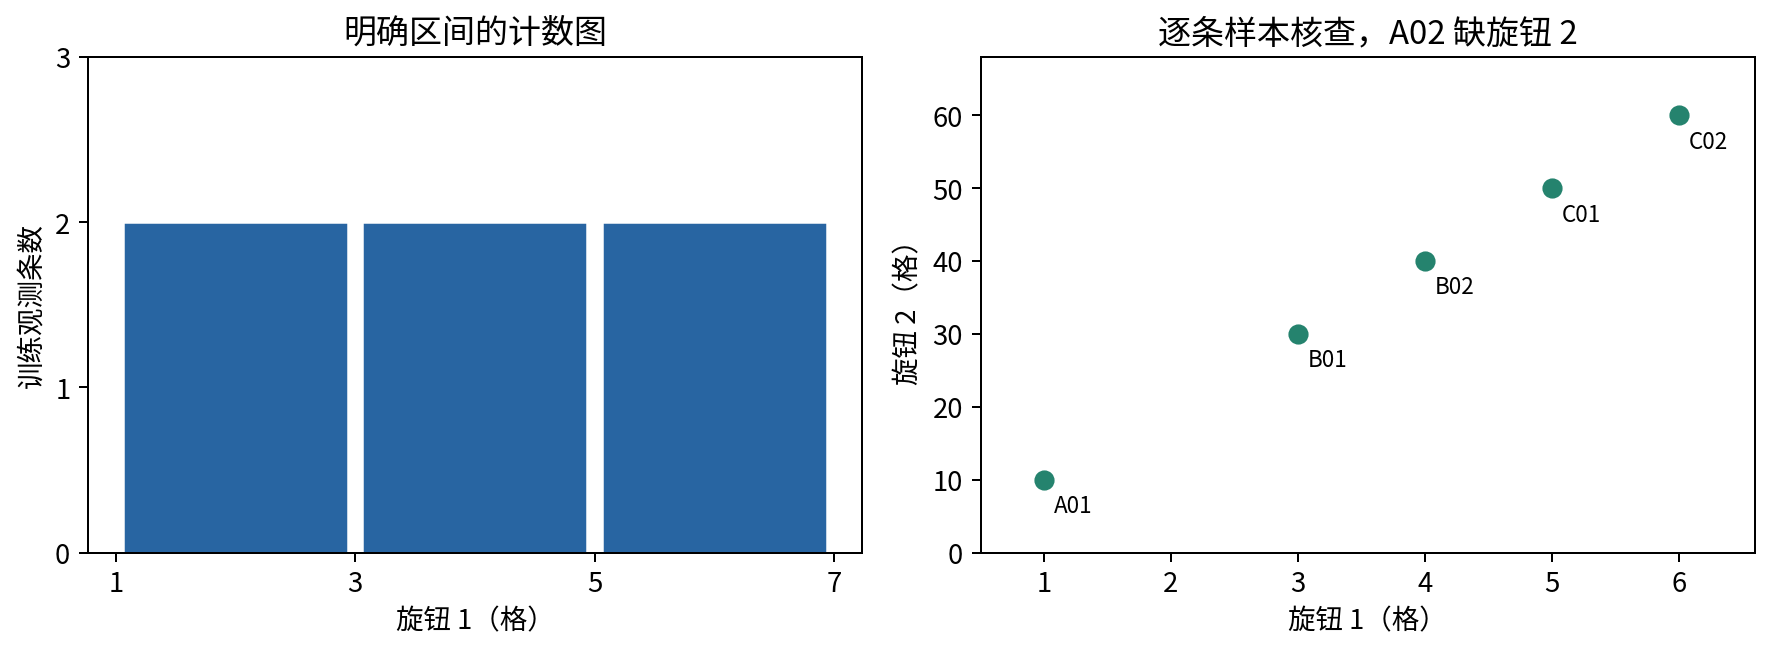

edges [1 3 5 7] counts [2 2 2]


In [6]:
import runpy
from IPython.display import Image, display
runpy.run_path(str(e.ROOT / "make_figures.py"))
display(Image(filename=str(e.ROOT / "figures/04_train_visuals.png")))
counts, edges = np.histogram(X["train"][:,0], bins=[1,3,5,7])
print("edges", edges, "counts", counts)

## 6 三个受控错误
所有错误只在副本或独立变量中演示，不覆盖正式state。

In [7]:
bad = copy.deepcopy(raw)
bad[-1]["knob1"] = "99"
for name, action in [("ID conflict", lambda:e.clean_records(bad)), ("future feature", lambda:e.feature_matrix(rows,("knob1","post_reading")))]:
    try:
        action()
    except ValueError as err:
        print(name, "blocked:", err)
    else:
        raise AssertionError("expected failure")
wrong_all = e.fit_preprocessor(e.feature_matrix(joined))
print("WRONG all-data mean:", wrong_all["mean"][1], "correct TRAIN:", state["mean"][1])
assert wrong_all["mean"][1] == 68
print(e.memorization_demo())

ID conflict blocked: conflicting record_id: A02
future feature blocked: feature allowlist is exactly knob1, knob2
WRONG all-data mean: 68.0 correct TRAIN: 38.0
{'same_entity_row_holdout_mae': 0.0, 'unseen_entity_holdout_mae': 23.666666666666668, 'row_split_entity_overlap': ['A', 'B', 'C', 'D', 'E', 'F'], 'unseen_entity_fallback': 6.0, 'note': 'two different evaluation targets; tiny constructed counterexample, not a performance estimate'}


## 7 留出变化不得改变训练状态
把留出值变大后，重新只拟合训练，结果必须逐项相同。

In [8]:
changed = copy.deepcopy(joined)
for row in changed:
    if row["record_id"] not in lists["train"]:
        row["knob1"] = "70000"
        row["knob2"] = "90000"
changed_parts = e.split_records(changed, lists)
again = e.fit_preprocessor(e.feature_matrix(changed_parts["train"]))
for key in state:
    np.testing.assert_array_equal(state[key], again[key])
print("held-out mutation leaves fitted state unchanged")

held-out mutation leaves fitted state unchanged


## 8 边界与独立数值核验
测试包括40组Fraction有理数oracle，未调用NumPy的mean/min/max来构造期望缩放结果。

In [9]:
test_ns = runpy.run_path(str(e.ROOT / "test_experiment.py"), run_name="__main__")
assert len(test_ns["PASSED"]) == 9

{
  "status": "passed",
  "test_groups": [
    "exact duplicate vs legitimate repeated/equal-feature observations",
    "schema, numeric parsing and finite-value failures",
    "identity join handles reversed labels and rejects missing or duplicate keys",
    "fixed lists exhaust rows without overlap and enforce target-specific entity isolation",
    "future field and silent feature-order changes rejected",
    "hand-calculated means, missing fraction, minmax scales and histogram counts",
    "empty, wrong shape, infinite, all-missing and constant TRAIN failures",
    "held-out changes cannot alter fitted training state",
    "40 independent Fraction fixtures and exact memorization 71/3 oracle"
  ],
  "independent_fraction_fixtures": 40
}


## 9 产生独立Notebook输出
目录与脚本输出分开，随后逐文件比较正式参数与账本。

In [10]:
report, ledger, saved_state = e.run(e.ROOT / "notebook_outputs")
assert report["test_targets_scored"] is False
assert report["fit_record_ids"] == lists["train"]
print("Notebook finished with explicit provenance.")

{
  "raw_rows": 13,
  "unique_rows": 12,
  "removed_exact_duplicate_ids": [
    "A02"
  ],
  "split_sizes": {
    "train": 6,
    "validation": 2,
    "test": 4
  },
  "train_description": {
    "knob1": {
      "rows": 6,
      "observed": 6,
      "missing": 0,
      "missing_fraction": 0.0,
      "sum": 21.0,
      "mean": 3.5,
      "min": 1.0,
      "max": 6.0
    },
    "knob2": {
      "rows": 6,
      "observed": 5,
      "missing": 1,
      "missing_fraction": 0.16666666666666666,
      "sum": 190.0,
      "mean": 38.0,
      "min": 10.0,
      "max": 60.0
    }
  },
  "fit_record_ids": [
    "A01",
    "A02",
    "B01",
    "B02",
    "C01",
    "C02"
  ],
  "feature_columns": [
    "knob1",
    "knob2"
  ],
  "forbidden_post_reading_after_prediction": true,
  "wrong_all_data_knob2_mean": 68.0,
  "correct_train_knob2_mean": 38.0,
  "train_knob1_histogram": [
    2,
    2,
    2
  ],
  "memory_counterexample": {
    "same_entity_row_holdout_mae": 0.0,
    "unseen_entity_holdou

## 解释结果
为何全量输入均值68仍然泄漏？为何验证缩放后大于1可以合法？为何身份记忆的0与71/3不是相同任务上的算法比较？答案应引用观测ID、时间与参数来源。